
#### 1. Snowflake Managed MCP Servers with Microsoft Copilot Studio [Click Here](https://www.youtube.com/watch?v=m21rmRyEfiU)
- https://docs.snowflake.com/en/user-guide/snowflake-cortex/cortex-agents-mcp
- Connecting **Snowflake Managed MCP (Model Context Protocol) Servers** with **Microsoft Copilot Studio**.



##### Learning Objectives

After completing these notes, you should understand:

1. What MCP (Model Context Protocol) is.
2. Why Snowflake Managed MCP Servers are useful.
3. How to expose Snowflake tools through MCP.
4. How to connect MCP Servers to Microsoft Copilot Studio.
5. How authentication works using Personal Access Tokens (PAT).
6. How Cortex Search and Stored Procedures can be exposed as MCP tools.


##### What is MCP?

**Model Context Protocol (MCP)** is an open standard that allows LLMs and AI agents to securely interact with:

- Databases
- APIs
- Applications
- Tools
- Services

Benefits:

- Standardized integration
- Secure communication
- Reusable tools
- No custom middleware required


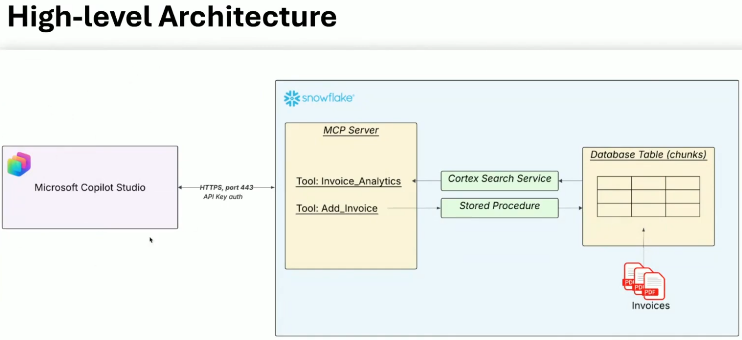

In [2]:
from IPython.display import Image
Image("./img/sfcc4.png")


##### Architecture Overview

```text
+----------------------+
| Microsoft Copilot    |
| Studio Agent         |
+----------+-----------+
           |
           | API Key / PAT
           v
+----------------------+
| Snowflake MCP Server |
+----------+-----------+
           |
   -------------------
   |                 |
   v                 v

Invoice Analytics   Add Invoice
(Cortex Search)     (Stored Procedure)

           |
           v

+----------------------+
| Snowflake Database   |
| Invoice Data         |
+----------------------+
```



##### MCP Tools Used in Demo

##### Tool 1: Invoice Analytics Service

Purpose:
- Query invoice data using natural language.
- Uses Cortex Search Service.
- Supports semantic and vector search.

Example Questions:
- How many invoices exist?
- What is the total invoice amount?
- Which companies have invoices?

---

##### Tool 2: Add Invoice

Purpose:
- Insert invoice data into Snowflake.
- Uses a stored procedure.
- Can process uploaded PDF invoices.

Example:
Upload a PDF → Extract invoice data → Store in Snowflake table.



##### Snowflake Components

##### Invoice Table

Stores:
- Invoice content
- Extracted text
- Metadata

##### Cortex Search Service

Provides:
- Vector search
- Semantic search
- Natural language retrieval

##### Stored Procedure

`ADD_INVOICE`

Responsibilities:
- Accept invoice content
- Parse data
- Insert into invoice table


##### Creating MCP Server in Snowflake

Traditional Method:
- Manually write MCP specification (YAML)

```sql
CREATE OR REPLACE MCP SERVER COPILOT_DB.STATS.FINANCE_MCP_SERVER
FROM SPECIFICATION $$
tools:
  - name: "invoice_search"
    type: "CORTEX_SEARCH_SERVICE_QUERY"
    identifier: "COPILOT_DB.STATS.INVOICE_SEARCH_SERVICE"
    description: "A tool that performs keyword and vector search over invoices."
    title: "Invoice Search Service"
  - name: "add_invoice"
    type: "GENERIC"
    identifier: "COPILOT_DB.STATS.ADD_INVOICE"
    description: "Adds a new invoice to the table"
    title: "Add Invoice"
    config:
      type: "procedure"
      warehouse: "COMPUTE_WH"
      input_schema:
        type: "object"
        properties:
          invoice_name:
            description: "Invoice file name"
            type: "string"
          invoice_content:
            description: "Invoice content"
            type: "string"

New Method:
- Use Snowflake Cortex Code Assistant

Prompt Example:

```text
Create MCP server in schema COPILOT_DB.STATS that will Expose two tools:
1. Invoice Search Service
2. ADD_INVOICE Stored Procedure
```


##### MCP Server Specification Concept

Each MCP Tool maps to a Snowflake object.

```text
MCP Server
│
├── Invoice Search Tool
│      └── Cortex Search Service
│
└── Add Invoice Tool
       └── Stored Procedure
```


```sql
SELECT * FROM COPILOT_DB.STATS.INVOICE_CHUNKED;
SHOW CORTEX SEARCH SERVICES;
SHOW MCP SERVERS;


##### Grant Access to MCP Server

Grant all privileges to a role:

```sql
GRANT ALL
ON MCP SERVER COPILOT_DB.STATS.FINANCE_MCP_SERVER
TO ROLE analyst;
```

This allows users with the role to access MCP tools.



##### Authentication Setup

##### Create User

```sql
CREATE USER copilot_pat_user;
```

##### Assign Role

```sql
GRANT ROLE analyst
TO USER copilot_pat_user;
```

##### Generate PAT

Generate a Personal Access Token (PAT) and use:

go to --> Governance --> Users & Roles --> select the user 'copilot_pat_user' --> Generate New token

```text
Bearer <token>
```


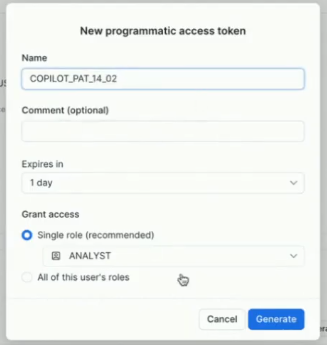

In [6]:
from IPython.display import Image
Image("./img/sfcc5.png")


##### Connecting MCP Server to Copilot Studio

Steps:

1. Create a new Copilot Agent.
2. Open Settings.
3. Disable:
   - Use General Knowledge
5. Enable:
   - File Uploads
   - Code Interpreter
6. Add Tool.. 
   - go to tools --> choose MCP --> Server name  :Snowflake MCP Invoices --> Description :  --> Server URL :  --> Authentication: API Key --> Header Name : Authorization --> create
7. Create a new connection --> paste the API token (Bearer <token>)
8. Save configuration.



##### Tool Discovery

After connection, Copilot automatically discovers MCP tools.

Example:

```text
Invoice Search
Add Invoice
```

You can:
- Enable all tools
- Enable selected tools only


##### Example Interaction

User:

```text
What is the total amount of all invoices?
```

Agent Flow:

```text
User Question
      ↓
Invoice Search Tool
      ↓
Snowflake Cortex Search
      ↓
Retrieve Data
      ↓
Formatted Response
```


##### Generating Charts

Example Prompt:

```text
Generate a pie chart showing each company
and their invoice amount.
```

Flow:

```text
Copilot
   ↓
Invoice Search Tool
   ↓
Retrieve Data
   ↓
Code Interpreter
   ↓
Pie Chart
```



# Best Practices

### MCP Tool Design

Provide:

- Clear tool names
- Detailed descriptions
- Usage instructions

Example:

```text
Invoice Search:
Use for invoice-related analytical questions.
```

This helps the agent choose the correct tool.



# Advantages of Snowflake Managed MCP

## Simplicity

Before:
- Custom integrations
- Additional middleware

Now:
- Native Snowflake MCP support

## Reusability

Build once:

```text
Snowflake MCP Server
       │
 ┌─────┼─────┐
 │     │     │
Copilot Other AI Clients
Studio
```

## Security

- Role-based access
- PAT authentication
- OAuth support



# Key Interview Questions

### Q1. What is MCP?
A protocol that enables AI models to securely interact with external tools and systems.

### Q2. Why use Snowflake Managed MCP?
It eliminates custom middleware and simplifies AI integrations.

### Q3. What can be exposed as MCP tools?
- Cortex Search Services
- Cortex Analyst
- Stored Procedures
- Custom business logic

### Q4. How does Copilot authenticate?
Using PAT tokens or OAuth.

### Q5. What is the benefit of Cortex Code Assistant?
Automatically generates MCP server specifications.



# Quick Revision Notes

- MCP = Standard protocol for AI tool integration.
- Snowflake now hosts MCP servers natively.
- Cortex Search can be exposed as MCP tools.
- Stored Procedures can be exposed as MCP tools.
- Copilot Studio consumes MCP tools directly.
- Authentication uses PAT or OAuth.
- Cortex Code Assistant can generate MCP specifications.
- One MCP server can serve multiple AI clients.
